# ChatGPT Analysis Review


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Data Cleaning

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Jagadeesh63/chatgpt_reviews/refs/heads/main/chatgpt_reviews.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [ ]:
print(df.head(5))

                              Review Id  \
0  6fb93778-651a-4ad1-b5ed-67dd0bd35aac   
1  81caeefd-3a28-4601-a898-72897ac906f5   
2  452af49e-1d8b-4b68-b1ac-a94c64cb1dd5   
3  372a4096-ee6a-4b94-b046-cef0b646c965   
4  b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da   

                                              Review  Ratings  \
0                                               good        5   
1                                               good        5   
2                                           nice app        5   
3                                           nice, ig        5   
4  this is a great app, the bot is so accurate to...        5   

           Review Date  
0  2024-08-23 19:30:05  
1  2024-08-23 19:28:18  
2  2024-08-23 19:22:59  
3  2024-08-23 19:20:50  
4  2024-08-23 19:20:39  


In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns)

Index(['review_id', 'review', 'ratings', 'review_date'], dtype='object')


In [ ]:
print(df.isnull().sum())

review_id      0
review         6
ratings        0
review_date    0
dtype: int64


In [ ]:
df['review'] = df['review'].fillna('')

In [ ]:
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

In [ ]:
df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce')

In [ ]:
print(df.isnull().sum())

review_id      0
review         0
ratings        0
review_date    0
dtype: int64


# Sentiment Analysis

In [ ]:
def get_sentiment_polarity(text):
  if pd.isna(text) or text == '':
    return 0
  blob = TextBlob(str(text))
  return blob.sentiment.polarity
df['sentiment_polarity'] = df['review'].apply(get_sentiment_polarity)

In [ ]:
def get_sentiment_category(polarity):
  if polarity > 0.1:
    return 'positive'
  elif polarity < -0.1:
    return 'negative'
  else:
    return 'neutral'
df['sentiment_category'] = df['sentiment_polarity'].apply(get_sentiment_category)

In [ ]:
def get_sentiment_subjectivity(text):
  if pd.isna(text) or text == '':
    return 0
  blob = TextBlob(str(text))
  return blob.sentiment.subjectivity
df['sentiment_subjectivity'] = df['review'].apply(get_sentiment_subjectivity)

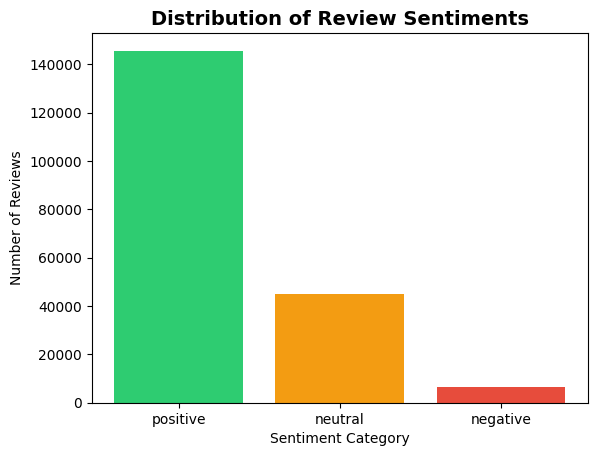

In [ ]:
sentiment_counts = df['sentiment_category'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
plt.title('Distribution of Review Sentiments', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

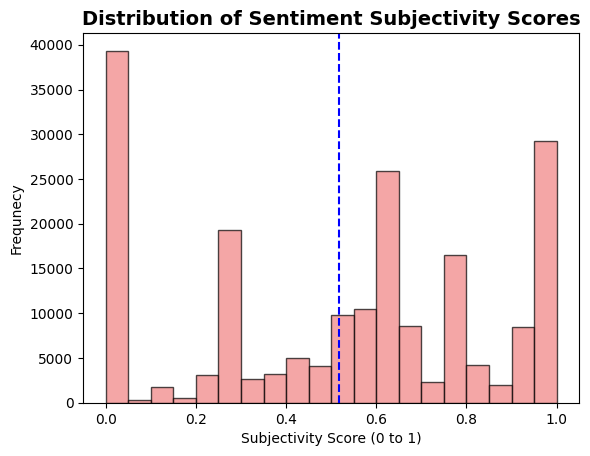

In [ ]:
plt.hist(df['sentiment_subjectivity'], bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
plt.axvline(df['sentiment_subjectivity'].mean(), color='blue', linestyle='--', label=f'Mean: {df['sentiment_subjectivity'].mean():.3f}')
plt.title('Distribution of Sentiment Subjectivity Scores', fontsize=14, fontweight='bold')
plt.xlabel('Subjectivity Score (0 to 1)')
plt.ylabel('Frequnecy')
plt.show()

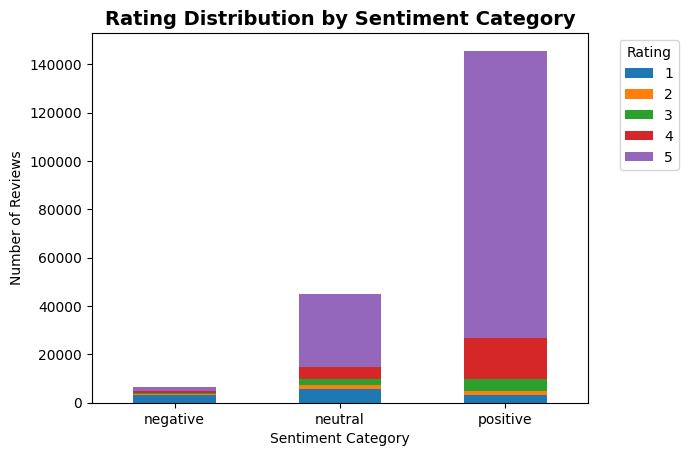

In [ ]:
sentiment_rating = df.groupby(['sentiment_category', 'ratings']).size().unstack(fill_value=0)
sentiment_rating.plot(kind='bar', stacked=True)
plt.title('Rating Distribution by Sentiment Category', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

# Analyzing Positive Features

In [ ]:
positive_reviews = df[df['sentiment_category'] == 'positive']['review']

In [ ]:
all_text = ' '.join(positive_reviews)

cleaned_text = re.sub(r'[^a-zA-Z\s]', '', all_text)
words = cleaned_text.split()

words = [word for word in words if len(word) > 2]

phrases = []
for i in range(len(words) - 1):
  if len(words[i]) > 2 and len(words[i+1]) > 2:
    phrases.append(f"{words[i]} {words[i+1]}")

for i in range(len(words) - 2):
  if all(len(word) > 2 for word in words[i:i+3]):
    phrases.append(f"{words[i]} {words[i+1]} {words[i+2]}")

phrase_freq = Counter(phrases)

pos_phrases = phrase_freq.most_common(10)


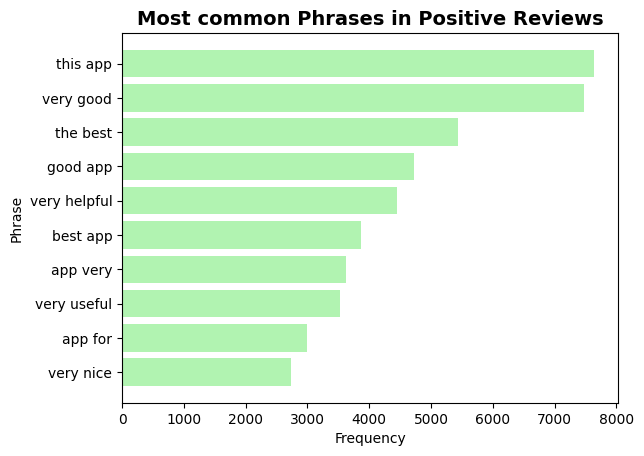

In [ ]:
if pos_phrases: # Check if the list is not empty
    phrases, phrase_counts = zip(*pos_phrases)

    plt.barh(range(len(phrases)), phrase_counts, color='lightgreen', alpha=0.7) # Changed to barh for horizontal bars
    plt.yticks(range(len(phrases)), phrases)
    plt.title('Most common Phrases in Positive Reviews', fontsize=14, fontweight='bold')
    plt.xlabel('Frequency')
    plt.ylabel('Phrase') # Added y-label for clarity
    plt.gca().invert_yaxis() # Invert y-axis to have the most common phrase at the top
    plt.show()
else:
    print("No positive phrases found to display.")


# Analyzing Negative Features

In [ ]:
negative_reviews = df[df['sentiment_category'] == 'negative']['review']

In [ ]:
all_text = ' '.join(negative_reviews.astype(str)).lower()

cleaned_text = re.sub(r'[^a-zA-Z\s]', '', all_text)
words = cleaned_text.split()

words = [word for word in words if len(word) > 2]

phrases = []
for i in range(len(words) - 1):
  if len(words[i]) > 2 and len(words[i+1]) > 2:
    phrases.append(f"{words[i]} {words[i+1]}")

for i in range(len(words) - 2):
  if all(len(word) > 2 for word in words[i:i+3]):
    phrases.append(f"{words[i]} {words[i+1]} {words[i+2]}")

phrase_freq = Counter(phrases)

neg_phrases = phrase_freq.most_common(10)

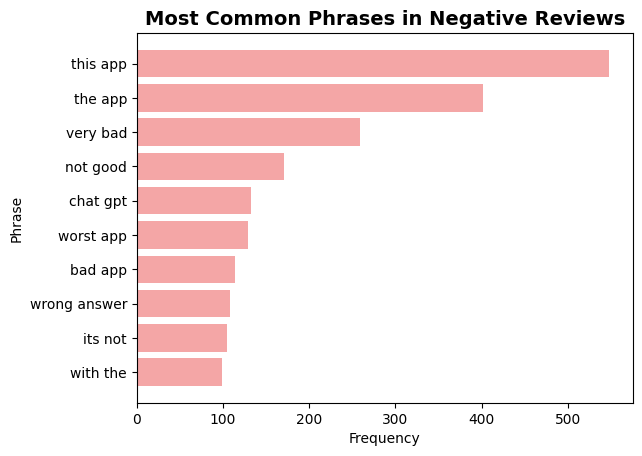

In [ ]:
if neg_phrases:
    phrases, phrase_counts = zip(*neg_phrases)

    # Create the horizontal bar chart directly with plt
    plt.barh(range(len(phrases)), phrase_counts, color='lightcoral', alpha=0.7)
    plt.yticks(range(len(phrases)), phrases)

    plt.title('Most Common Phrases in Negative Reviews', fontsize=14, fontweight='bold')
    plt.xlabel('Frequency')
    plt.ylabel('Phrase')
    plt.gca().invert_yaxis()

    plt.show()
else:
    print("No negative phrases found to display.")

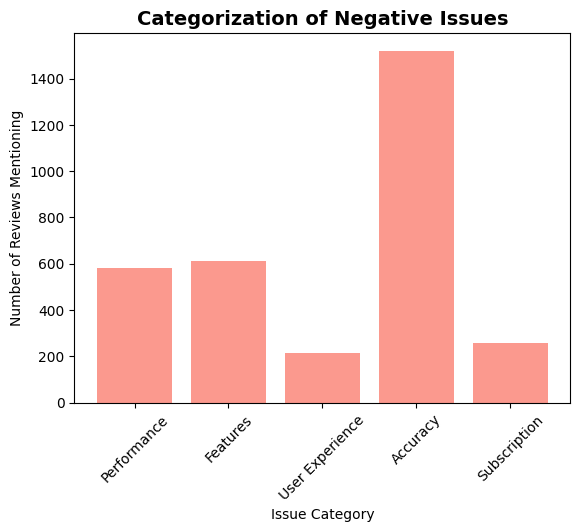

In [ ]:
issue_categories = {
    'Performance': ['slow', 'lag', 'crash', 'freeze', 'glitch', 'bug', 'error'],
    'Features': ['missing', 'lack', 'need', 'want', 'should', 'feature'],
    'User Experience': ['confusing', 'difficult', 'hard', 'complicated', 'interface'],
    'Accuracy': ['wrong', 'incorrect', 'bad', 'poor', 'inaccurate', 'mistake'],
    'Subscription': ['expensive', 'price', 'cost', 'pay', 'subscription', 'money']
}

category_counts = {}
for category, keywords in issue_categories.items():
  count = 0
  for review in negative_reviews:
    if any(keyword in str(review).lower() for keyword in keywords):
      count += 1
  category_counts[category] = count

categories = list(category_counts.keys())
counts = list(category_counts.values())

plt.bar(categories, counts, color='salmon', alpha=0.8)
plt.title('Categorization of Negative Issues', fontsize=14, fontweight='bold')
plt.xlabel('Issue Category')
plt.ylabel('Number of Reviews Mentioning')
plt.xticks(rotation=45)
plt.show()


# Analyze Neutral Features

In [ ]:
neutral_reviews = df[df['sentiment_category'] == 'neutral']

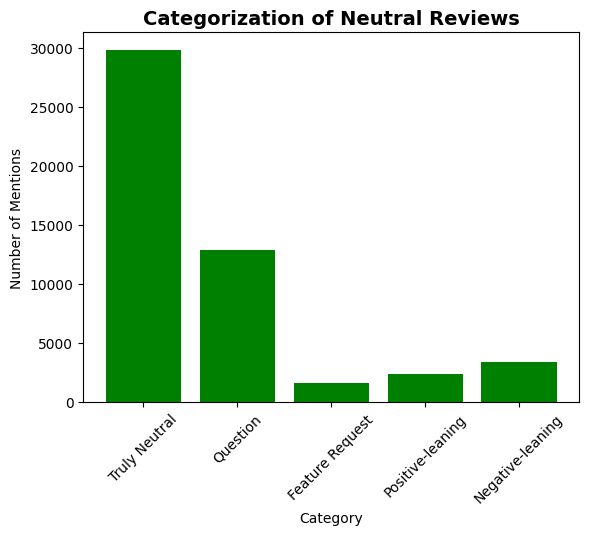

In [ ]:
neutral_texts = neutral_reviews['review']

keyword_map = {
    'Feature Request': ['add', 'include', 'feature', 'option', 'setting', 'would like', 'wish', 'hope'],
    'Question': ['how', 'what', 'why', 'when', 'where', 'can', 'does', 'is', '?'],
    'Positive-leaning': ['good', 'nice', 'ok', 'fine', 'decent', 'works'],
    'Negative-leaning': ['but', 'however', 'issue', 'problem', 'concern', 'could be better'],
}

neutral_categories = []

for text in neutral_texts:
  text_lower = str(text).lower()
  categories = []
  for label, keywords in keyword_map.items():
    if any(keyword in text_lower for keyword in keywords):
      categories.append(label)

  if not categories:
    categories.append('Truly Neutral')

  neutral_categories.extend(categories)

category_counts = Counter(neutral_categories)

if category_counts:
  plt.figure()

  categories = list(category_counts.keys())
  counts = list(category_counts.values())

  plt.bar(categories, counts, color='green')
  plt.title('Categorization of Neutral Reviews', fontsize=14, fontweight='bold')
  plt.xlabel('Category')
  plt.ylabel('Number of Mentions')
  plt.xticks(rotation=45)
  plt.show()

# Review Evolution Over Time

In [ ]:
df['Review_Month'] = df['review_date'].dt.to_period('M')
df['Review_Quarter'] = df['review_date'].dt.to_period('Q')

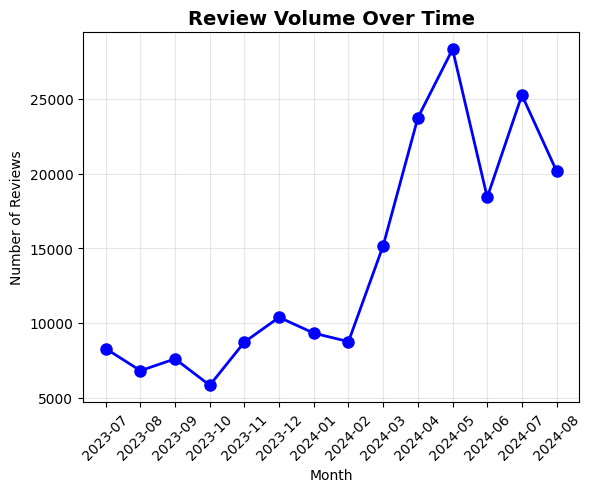

In [ ]:
monthly_counts = df.groupby('Review_Month').size()
plt.plot(monthly_counts.index.astype(str), monthly_counts.values, marker='o', linewidth=2, markersize=8, color='blue')
plt.title('Review Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

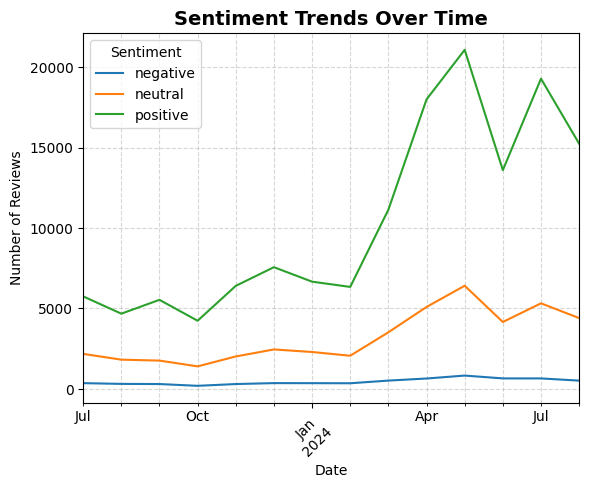

In [ ]:
df['review_date'] = pd.to_datetime(df['review_date'])

sentiment_over_time = df.groupby([df['review_date'].dt.to_period('M'), 'sentiment_category']) \
                        .size().unstack(fill_value=0)

sentiment_over_time.index = sentiment_over_time.index.to_timestamp()
sentiment_over_time.plot()

plt.title('Sentiment Trends Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.show()